# RQ1: Baseline Model Comparison

**Research Question:** Which baseline classifiers show the most promise for mortality prediction before advanced tuning?

Comparing three standard classifiers — Logistic Regression, Decision Tree, and KNN — using identical preprocessing and the default decision threshold (0.5). All models use `class_weight='balanced'` where available to handle class imbalance.

Dataset shape: (10000, 14)

Class distribution (mortality):
mortality
0    9727
1     273
Name: count, dtype: int64

Minority class ratio: 2.73%
Train size: 8000  |  Test size: 2000
Train class balance: 2.73% positive


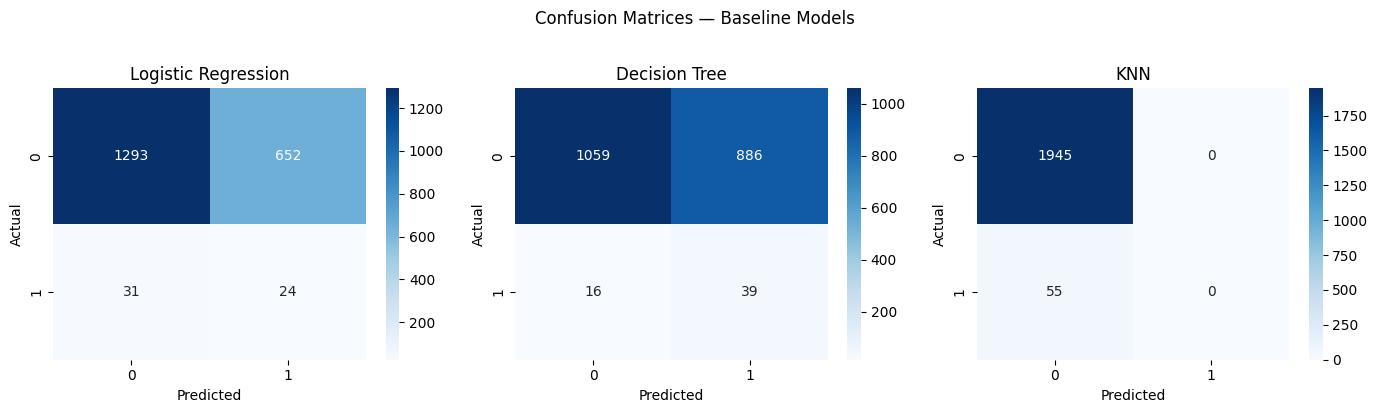


RQ1 Results:

              Model  Accuracy  Precision  Recall    F1
Logistic Regression     0.658      0.036   0.436 0.066
      Decision Tree     0.549      0.042   0.709 0.080
                KNN     0.973      0.000   0.000 0.000


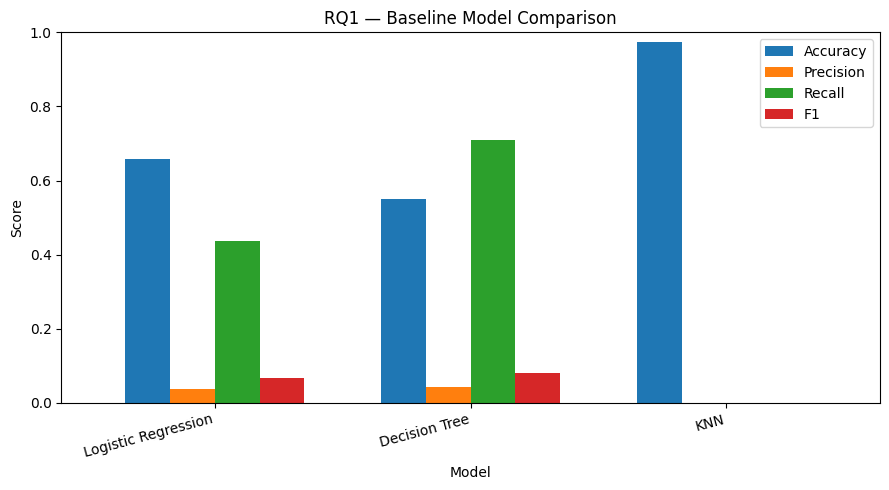


Note: Accuracy is misleading on imbalanced data.
Logistic Regression and Decision Tree use class_weight='balanced';
KNN does not, so it will favour the majority class.


In [2]:
#IMPORTS & SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

#LOAD DATASET
df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')

print("Dataset shape:", df.shape)
print("\nClass distribution (mortality):")
print(df['mortality'].value_counts())
print(f"\nMinority class ratio: {df['mortality'].mean():.2%}")

# Drop patient_id if present (non-feature identifier column)
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

y = df['mortality']
X = df.drop(columns=['mortality'])
#PREPROCESSING PIPELINE
# Each model gets its own fresh preprocessor instance to avoid fitting state
# leaking between models in the loop.

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

def make_preprocessor():
    """Returns a fresh ColumnTransformer each time — avoids reuse bugs."""
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols)
    ])

#TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train class balance: {y_train.mean():.2%} positive")
#MODELS
# KNN has no class_weight; all others use 'balanced'.
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=6))
    ]),
    'KNN': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

#TRAIN + EVALUATE
results = []

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    results.append([
        name,
        round(accuracy_score(y_test, y_pred), 3),
        round(precision_score(y_test, y_pred, zero_division=0), 3),
        round(recall_score(y_test, y_pred, zero_division=0), 3),
        round(f1_score(y_test, y_pred, zero_division=0), 3)
    ])

plt.suptitle('Confusion Matrices — Baseline Models', y=1.02)
plt.tight_layout()
plt.savefig('rq1_confusion_matrices.pdf', bbox_inches='tight')
plt.show()
#RESULTS TABLE
results_df = pd.DataFrame(results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])

print("\nRQ1 Results:\n")
print(results_df.to_string(index=False))

results_df.to_csv('rq1_table.csv', index=False)

#BAR CHART
ax = results_df.set_index('Model')[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(9, 5), width=0.7
)
plt.title('RQ1 — Baseline Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('rq1_bar_chart.pdf')
plt.show()

print("\nNote: Accuracy is misleading on imbalanced data.")
print("Logistic Regression and Decision Tree use class_weight='balanced';")
print("KNN does not, so it will favour the majority class.")
